In [1]:
# !pip install ta
# !pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ta.momentum import RSIIndicator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor

# 1. Data Collection

In [3]:
# initializing stock variable
ticker = "GOOG"

# getting and displaying the data of 11 years of GOOG's stock history
data = yf.download(ticker, start="2014-01-01", end="2026-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2014-01-02,27.498323,27.612703,27.378263,27.556132,73129082
2014-01-03,27.297728,27.592444,27.295998,27.544767,66917888
2014-01-06,27.602079,27.640122,27.333301,27.495606,71037271
2014-01-07,28.134201,28.154706,27.696945,27.791807,102486711
2014-01-08,28.192747,28.343194,27.996598,28.310585,90036218


In [4]:
data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

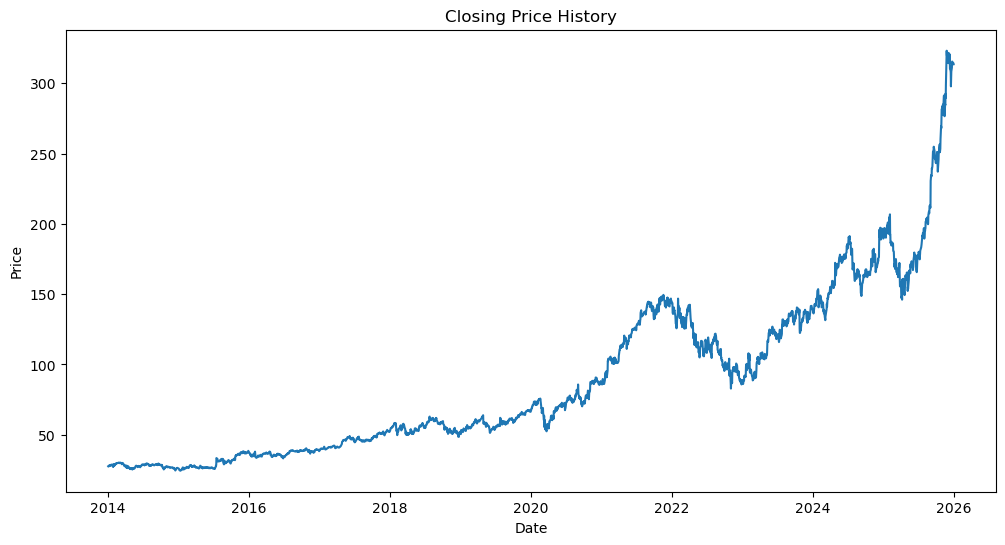

In [5]:
# display the closing price history
plt.figure(figsize=(12,6))

plt.plot(data["Close"])

plt.title("Closing Price History")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

# 2. Feature Engineering

In [6]:
# change in close price each day
data["Price_Change"] = data["Close"].diff()

# 20 day moving avg
data["SMA20"] = data["Close"].rolling(window=20).mean()

# 50 day moving avg
data["SMA50"] = data["Close"].rolling(window=50).mean()

# pct change between rows, today and yesterday
data["Daily_Return"] = data["Close"].pct_change()

# standard deviation of last 20 days, higher value = greater volatility
data["Volatility_20"] = data["Daily_Return"].rolling(window=20).std()

# yesterday's price to help predict tomorrow's price
data["Lag1_Close"] = data["Close"].shift(1)

# RSI > 70: overbought
# RSI < 30: oversold
rsi = RSIIndicator(close=data["Close"].squeeze(), window=14)

data["RSI_14"] = rsi.rsi()

# 3. Prediction Targets

In [7]:
# Define target: shift Close price to align today's data with tomorrow's outcome
data["Tomorrow_Close"] = data["Close"].shift(-1)

# Tomorrow > Today: 1 (price went UP)
# Tomorrow <= Today: 0 (price went DOWN)
data["Direction"] = (data["Tomorrow_Close"] > data["Close"].squeeze()).astype(int)

In [8]:
# removing null values, rows contain null values because:
# SMA20 needs 20 days
# SMA50 needs 50 days
# RSI needs 14 days
data = data.dropna()

In [9]:
data.head(10)

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
Date,,,,,,,,,,,,,,
2014-03-14,28.972651,29.419049,28.965980,29.199678,92099924,-0.401682,29.845237,28.917411,-0.013675,0.007145,29.374332,41.274437,29.449432,1
2014-03-17,29.449432,29.572211,29.103826,29.131989,86808163,0.476782,29.832021,28.956433,0.016456,0.008132,28.972651,49.471724,29.922756,1
2014-03-18,29.922756,29.929427,29.473147,29.512921,72872123,0.473324,29.832490,29.008933,0.016072,0.008805,29.449432,56.033063,29.626062,0
2014-03-19,29.626062,29.940789,29.506494,29.936095,64757822,-0.296694,29.828673,29.049413,-0.009915,0.008948,29.922756,51.517159,29.574432,0
2014-03-20,29.574432,29.881994,29.529965,29.643355,67640587,-0.051630,29.820089,29.078218,-0.001743,0.008948,29.626062,50.750645,29.225615,0
2014-03-21,29.225615,29.882491,29.211040,29.800473,128821050,-0.348818,29.794458,29.098875,-0.011795,0.009313,29.574432,45.793275,28.605303,0
2014-03-24,28.605303,29.271565,28.309349,29.254026,121939352,-0.620312,29.727042,29.112556,-0.021225,0.010152,29.225615,38.576705,28.624819,1
2014-03-25,28.624819,28.899526,28.335291,28.804664,96769361,0.019516,29.651349,29.126657,0.000682,0.009985,28.605303,38.902928,27.963993,0


In [10]:
data.describe()

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
count,2968.000000,2968.000000,2968.000000,2968.000000,2.968000e+03,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000
mean,89.223932,90.152994,88.253985,89.172637,3.080534e+07,0.096009,88.321189,86.936051,0.000958,0.016470,89.127923,54.410089,89.319824,0.536388
std,58.519058,59.193920,57.818726,58.490691,1.602053e+07,1.987103,57.127581,54.994547,0.017871,0.007184,58.383213,11.636014,58.653324,0.498758
min,24.360077,24.529517,24.113286,24.463938,1.584340e+05,-14.344025,25.322609,25.747297,-0.111008,0.002915,24.360077,24.077295,24.360077,0.000000
25%,40.854213,41.024950,40.684982,40.806979,2.099485e+07,-0.469404,40.403832,39.928708,-0.007289,0.011174,40.840081,45.916409,40.868844,0.000000
50%,66.032871,66.581875,65.304108,65.924022,2.678372e+07,0.061327,65.012167,63.812097,0.001093,0.015128,65.832764,54.725690,66.231491,1.000000
75%,131.058022,132.451462,129.586344,131.023059,3.549650e+07,0.694292,132.028309,130.786930,0.009931,0.020493,131.016747,62.782587,131.128090,1.000000
max,323.201294,328.224474,319.546256,326.356983,2.232980e+08,19.067032,314.233405,295.855741,0.160524,0.055626,323.201294,89.071289,323.201294,1.000000


In [11]:
data.columns

MultiIndex([(         'Close', 'GOOG'),
            (          'High', 'GOOG'),
            (           'Low', 'GOOG'),
            (          'Open', 'GOOG'),
            (        'Volume', 'GOOG'),
            (  'Price_Change',     ''),
            (         'SMA20',     ''),
            (         'SMA50',     ''),
            (  'Daily_Return',     ''),
            ( 'Volatility_20',     ''),
            (    'Lag1_Close',     ''),
            (        'RSI_14',     ''),
            ('Tomorrow_Close',     ''),
            (     'Direction',     '')],
           names=['Price', 'Ticker'])

# 4. Feature Engineering

In [12]:
data["Lag2_Close"] = data["Close"].shift(2)
data["Lag3_Close"] = data["Close"].shift(3)
data["Lag5_Close"] = data["Close"].shift(5)
data = data.dropna()

C:\Users\denim\AppData\Local\Temp\ipykernel_14484\2040797139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Lag2_Close"] = data["Close"].shift(2)
C:\Users\denim\AppData\Local\Temp\ipykernel_14484\2040797139.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Lag3_Close"] = data["Close"].shift(3)
C:\Users\denim\AppData\Local\Temp\ipykernel_14484\2040797139.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [13]:
# predictor variables used by the models
features = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "Price_Change",
    "SMA20",
    "SMA50",
    "Daily_Return",
    "Volatility_20",
    "Lag1_Close",
    "Lag2_Close",
    "Lag3_Close",
    "Lag5_Close",
    "RSI_14"
]

# feature matrix
X = data[features].copy()

# Target variable for price prediction(regression)
y_price = data["Tomorrow_Close"]

# Target variable for price direction prediction(classification)
y_direction = data["Direction"]

In [14]:
X.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in X.columns] 

In [15]:
X.columns

Index(['Close_GOOG', 'High_GOOG', 'Low_GOOG', 'Open_GOOG', 'Volume_GOOG',
       'Price_Change_', 'SMA20_', 'SMA50_', 'Daily_Return_', 'Volatility_20_',
       'Lag1_Close_', 'Lag2_Close_', 'Lag3_Close_', 'Lag5_Close_', 'RSI_14_'],
      dtype='object')

# 5. Splitting data for training and testing

In [16]:
# Splitting data for price
# shuffle off(time series data) so it doesn't train on new data and test on old, 
# Training size: 80%, Testing size: 20%
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X,
    y_price,
    test_size = 0.2,
    shuffle = False
)
X_train_price.shape, X_test_price.shape, y_train_price.shape, y_test_price.shape

((2370, 15), (593, 15), (2370,), (593,))

In [17]:
# Splitting data for direction following the same rules as above
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X,
    y_direction,
    test_size = 0.2,
    shuffle = False
)
X_train_dir.shape, X_test_dir.shape, y_train_dir.shape, y_test_dir.shape

((2370, 15), (593, 15), (2370,), (593,))

In [18]:
lr_model = LinearRegression()

lr_model.fit(X_train_price, y_train_price)

LinearRegression()

In [19]:
lr_predictions = lr_model.predict(X_test_price)

# 6. Evaluating model performance

In [20]:
mae = mean_absolute_error(y_test_price, lr_predictions)

rmse = np.sqrt(mean_squared_error(y_test_price, lr_predictions))

print(f"Linear Regression MAE: {mae:.2f}")
print(f"Linear Regression RMSE: {rmse:.2f}")

Linear Regression MAE: 2.42
Linear Regression RMSE: 3.47


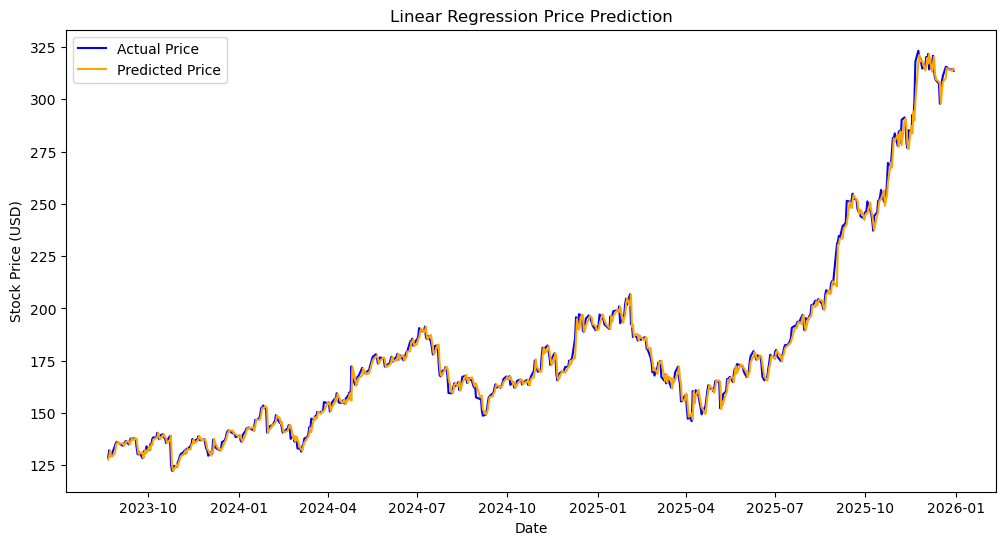

In [21]:
plt.figure(figsize=(12,6))

plt.plot(y_test_price.index, y_test_price.values, label="Actual Price", color="blue")
plt.plot(y_test_price.index, lr_predictions, label="Predicted Price",color="orange")

plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")

plt.title("Linear Regression Price Prediction")
plt.legend()
plt.show()

# 7. Evaluating direction accuracy

In [22]:
# Predicted price > today's price: stock goes UP
# Predicted price =< today's price: stock goes DOWN

# Force both to be flat 1D arrays before comparing
pred_vals = lr_predictions.ravel()
actual_closes = X_test_price["Close_GOOG"].values.ravel()

# This will now be shape (594,)
predicted_direction = (pred_vals > actual_closes).astype(int)


direction_accuracy = accuracy_score(y_test_dir, predicted_direction)
print(f"Directional accuracy: {direction_accuracy:.2%}")

Directional accuracy: 53.79%


In [23]:
print("Linear Regression confusion matrix:")
confusion_matrix(y_test_dir, predicted_direction)

Linear Regression confusion matrix:


array([[156, 101],
       [173, 163]])

The model shows a balanced directional accuracy of ~52%. While the price predictions (MAE/RMSE) are tight, the model is slightly more prone to False Negatives (179) than False Positives (104), suggesting it is cautious about predicting upward trends. The model is currently more likely to miss an upward move (predicting Down when it went Up) than it is to give a false alarm (predicting Up when it went Down).

# 8. Random Forest

In [24]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42)

X_train_rf = X_train_price.drop(columns=["Close_GOOG"])
X_test_rf = X_test_price.drop(columns=["Close_GOOG"])

rf_model.fit(X_train_rf, y_train_price)

rf_predictions = rf_model.predict(X_test_rf)

rf_mae = mean_absolute_error(y_test_price, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test_price, rf_predictions))

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")

Random Forest MAE: 35.90
Random Forest RMSE: 55.80


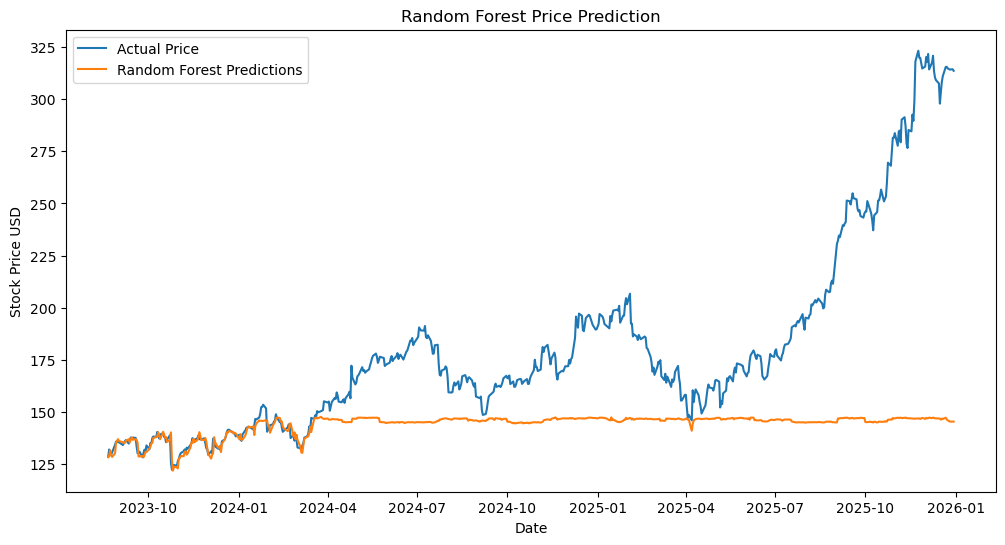

In [25]:
plt.figure(figsize=(12,6))

plt.plot(y_test_price.index, y_test_price.values, label="Actual Price")
plt.plot(y_test_price.index, rf_predictions, label="Random Forest Predictions")

plt.xlabel("Date")
plt.ylabel("Stock Price USD")
plt.title("Random Forest Price Prediction")

plt.legend()

plt.show()

In [26]:
rf_pred_values = rf_predictions.ravel()

rf_direction = (rf_pred_values > actual_closes).astype(int)

rf_direction_accuracy = accuracy_score(y_test_dir, rf_direction)

print("Random Forest Directional Accuracy:", rf_direction_accuracy)

Random Forest Directional Accuracy: 0.4671163575042159


In [27]:
rf_cm = confusion_matrix(y_test_dir, rf_direction)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[233  24]
 [292  44]]
